In [1]:
pip install requests pandas openpyxl

In [7]:
import requests
import pandas as pd
import time

def fetch_steam_reviews(appid, total_desired=100):
    reviews_list = []
    cursor = '*'  # El cursor inicial siempre es '*'

    print(f"Iniciando descarga de {total_desired} reseñas para el AppID: {appid}...")

    while len(reviews_list) < total_desired:
        # Parámetros de la URL
        url = f'https://store.steampowered.com/appreviews/{appid}'
        params = {
            'json': 1,
            'filter': 'recent',  # Puede ser 'all', 'recent', 'updated'
            'language': 'spanish', # O 'latam' / 'english'
            'day_range': 365,
            'cursor': cursor,
            'review_type': 'all', # 'positive', 'negative' o 'all'
            'purchase_type': 'all'
        }

        response = requests.get(url, params=params)
        data = response.json()

        # Si no hay más reseñas, rompemos el bucle
        if 'reviews' not in data or not data['reviews']:
            break

        for rev in data['reviews']:
            reviews_list.append({
                'Reseña': rev['review'],
                'Voto': 'Positiva' if rev['voted_up'] else 'Negativa',
                'Horas_Jugadas': rev['author']['playtime_forever'] / 60, # Convertir a horas
                'Recomendado': rev['voted_up']
            })

            # Detenerse si alcanzamos el número deseado
            if len(reviews_list) >= total_desired:
                break

        # Actualizamos el cursor para la siguiente página
        cursor = data['cursor']
        print(f"Progreso: {len(reviews_list)} reseñas obtenidas...")

        # Pausa breve para no saturar el servidor (buena práctica)
        time.sleep(0.5)

    return pd.DataFrame(reviews_list)

# --- CONFIGURACIÓN Y EJECUCIÓN ---
APP_ID = 105600  # Terraria
CANTIDAD = 800   # Número de reseñas que quieres bajar

df_reviews = fetch_steam_reviews(APP_ID, CANTIDAD)

# Guardar resultados
df_reviews.to_csv('reseñas_steam.csv', index=False, encoding='utf-8-sig')
print("\n¡Listo! Archivo 'reseñas_steam.csv' creado con éxito.")

# Mostrar un pequeño resumen
print(df_reviews['Voto'].value_counts())

Iniciando descarga de 800 reseñas para el AppID: 105600...
Progreso: 20 reseñas obtenidas...
Progreso: 40 reseñas obtenidas...
Progreso: 60 reseñas obtenidas...
Progreso: 80 reseñas obtenidas...
Progreso: 100 reseñas obtenidas...
Progreso: 120 reseñas obtenidas...
Progreso: 140 reseñas obtenidas...
Progreso: 160 reseñas obtenidas...
Progreso: 180 reseñas obtenidas...
Progreso: 200 reseñas obtenidas...
Progreso: 220 reseñas obtenidas...
Progreso: 240 reseñas obtenidas...
Progreso: 260 reseñas obtenidas...
Progreso: 280 reseñas obtenidas...
Progreso: 300 reseñas obtenidas...
Progreso: 320 reseñas obtenidas...
Progreso: 340 reseñas obtenidas...
Progreso: 360 reseñas obtenidas...
Progreso: 380 reseñas obtenidas...
Progreso: 400 reseñas obtenidas...
Progreso: 420 reseñas obtenidas...
Progreso: 440 reseñas obtenidas...
Progreso: 460 reseñas obtenidas...
Progreso: 480 reseñas obtenidas...
Progreso: 500 reseñas obtenidas...
Progreso: 520 reseñas obtenidas...
Progreso: 540 reseñas obtenidas...


In [3]:
pip install nltk pandas matplotlib wordcloud

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!



--- ANÁLISIS 1: Distribución de Sentimientos ---
Voto
Positiva    785
Negativa     15
Name: count, dtype: int64

--- ANÁLISIS 2: Top 10 palabras generales ---
[('mejor', 75), ('bueno', 73), ('doot', 65), ('buen', 61), ('bap', 61), ('terraria', 59), ('juegazo', 49), ('cht', 42), ('vida', 40), ('god', 38)]

--- ANÁLISIS 3: Top palabras por Sentimiento ---
Positivas: [('mejor', 75), ('bueno', 72), ('doot', 65), ('buen', 61), ('bap', 61), ('terraria', 59), ('juegazo', 48), ('cht', 42), ('vida', 38), ('god', 38)]
Negativas: [('puede', 3), ('eliminen', 3), ('hizo', 2), ('peor', 2), ('vida', 2), ('horas', 2), ('aun', 2), ('zoologa', 2), ('quita', 2), ('ropa', 2)]


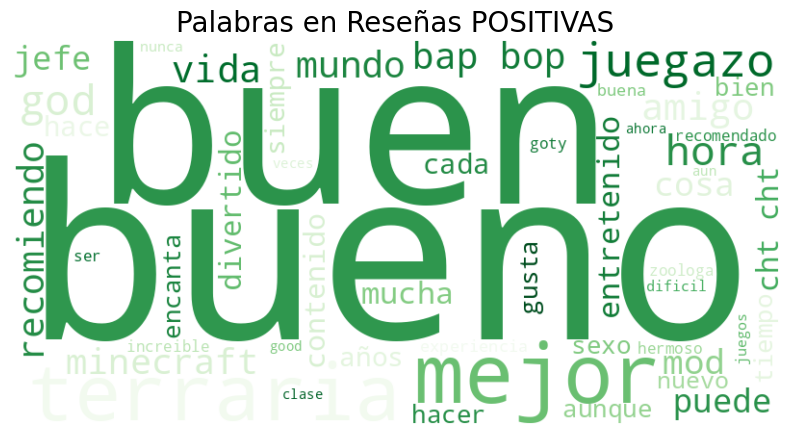

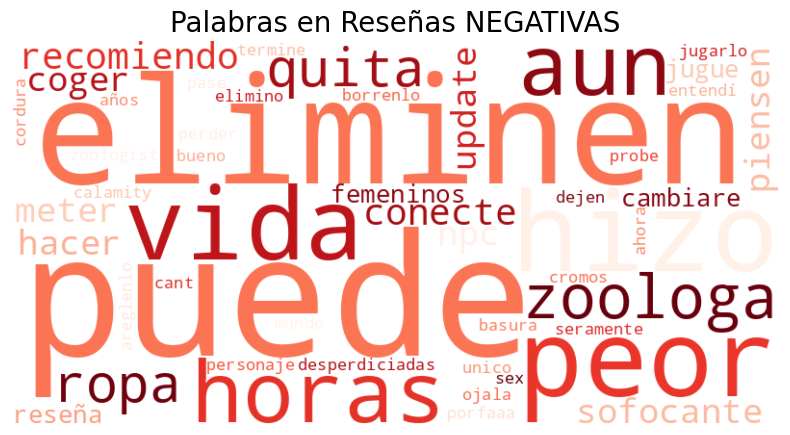

In [8]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Descargar recursos necesarios de NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') # Add this line to download the specific resource

# 1. CARGA DE DATOS
# Asumiendo que el archivo se llama 'reseñas_steam.csv' del paso anterior
df = pd.read_csv('reseñas_steam.csv')

# --- LIMPIEZA DE DATOS ---
def limpiar_texto(texto):
    if not isinstance(texto, str): return ""
    # Convertir a minúsculas
    texto = texto.lower()
    # Eliminar URLs
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto, flags=re.MULTILINE)
    # Eliminar caracteres especiales y números (dejamos solo letras)
    texto = re.sub(r'[^a-záéíóúñü\s]', '', texto)
    # Eliminar espacios extra
    texto = texto.strip()
    return texto

df['texto_limpio'] = df['Reseña'].apply(limpiar_texto)

# --- TOKENIZACIÓN Y ELIMINACIÓN DE STOPWORDS ---
stop_words = set(stopwords.words('spanish'))
# Puedes añadir palabras comunes de Steam que no aportan valor
stop_words.update(['juego', 'jugar', 'steam', 'mas', 'si', 'tan', 'solo'])

def tokenizar_y_filtrar(texto):
    tokens = word_tokenize(texto, language='spanish') # Especificar el idioma español
    # Filtrar por longitud y si es stopword
    tokens_filtrados = [w for w in tokens if w not in stop_words and len(w) > 2]
    return tokens_filtrados

df['tokens'] = df['texto_limpio'].apply(tokenizar_y_filtrar)

# --- ANÁLISIS 1: Conteo de Comentarios Positivos vs Negativos ---
print("\n--- ANÁLISIS 1: Distribución de Sentimientos ---")
conteo_votos = df['Voto'].value_counts()
print(conteo_votos)

# --- ANÁLISIS 2: Conteo de Palabras Más Frecuentes (General) ---
todas_las_palabras = [palabra for lista in df['tokens'] for palabra in lista]
frecuencia_general = Counter(todas_las_palabras).most_common(10)
print("\n--- ANÁLISIS 2: Top 10 palabras generales ---")
print(frecuencia_general)

# --- ANÁLISIS 3: Palabras en Comentarios Positivos vs Negativos ---
pos_tokens = [p for lista in df[df['Voto'] == 'Positiva']['tokens'] for p in lista]
neg_tokens = [p for lista in df[df['Voto'] == 'Negativa']['tokens'] for p in lista]

frecuencia_pos = Counter(pos_tokens).most_common(10)
frecuencia_neg = Counter(neg_tokens).most_common(10)

print("\n--- ANÁLISIS 3: Top palabras por Sentimiento ---")
print("Positivas:", frecuencia_pos)
print("Negativas:", frecuencia_neg)

# --- ANÁLISIS 4: Nube de Palabras por Sentimiento ---
def generar_nube(lista_palabras, titulo, color):
    texto_nube = " ".join(lista_palabras)
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=color, max_words=50).generate(texto_nube)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(titulo, fontsize=20)
    plt.axis('off')
    plt.show()

# Generar las nubes
if pos_tokens:
    generar_nube(pos_tokens, "Palabras en Reseñas POSITIVAS", "Greens")
if neg_tokens:
    generar_nube(neg_tokens, "Palabras en Reseñas NEGATIVAS", "Reds")

# Conclusion

No se puede confiar mucho en las reseñas de Steam, principalmente porque las reseñas negativas suelen ser porque no se pueden mantener relaciones intimas con personajes del juego 🗿


Esto tambien indica que según la plataforma de la que se realizara la extracción se debera tener en cuenta criterios un poco más especificos, pues lo que se suele calificar como negativo puede ser una tonteria.